# Análisis Sísmico del Perú (2022-2024)

Exploración de actividad sísmica registrada por USGS para el territorio peruano.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

PALETA = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

## Extracción de datos desde USGS

In [2]:
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
params = {
    "format": "geojson",
    "starttime": "2022-01-01",
    "endtime": "2024-12-31",
    "minlatitude": -18.35,
    "maxlatitude": -0.04,
    "minlongitude": -81.33,
    "maxlongitude": -68.65,
    "minmagnitude": 3.0,
    "orderby": "time",
    "limit": 5000,
}
resp = requests.get(url, params=params, timeout=60)
data = resp.json()

registros = []
for feat in data["features"]:
    props = feat["properties"]
    coords = feat["geometry"]["coordinates"]
    registros.append({
        "fecha": pd.Timestamp(props["time"], unit="ms"),
        "magnitud": props["mag"],
        "profundidad_km": coords[2],
        "latitud": coords[1],
        "longitud": coords[0],
        "lugar": props.get("place", ""),
    })

sismos = pd.DataFrame(registros)
sismos["anio"] = sismos["fecha"].dt.year
sismos["mes"] = sismos["fecha"].dt.month

print(f"Registros: {len(sismos)}")
sismos.head()

Registros: 902


,fecha,magnitud,profundidad_km,latitud,longitud,lugar,anio,mes
0,2024-12-23 23:00:52.184,4.4,181.076,-1.6086,-77.9319,"10 km NNE of Palora, Ecuador",2024,12
1,2024-12-22 21:38:37.166,4.9,94.270,-10.3585,-77.4718,"2 km NE of Copa, Peru",2024,12
2,2024-12-21 21:25:34.409,4.5,55.941,-15.1752,-74.9179,"21 km E of Minas de Marcona, Peru",2024,12
3,2024-12-19 13:37:44.262,4.3,109.098,-15.3952,-73.1730,"7 km SE of Tauria, Peru",2024,12
4,2024-12-15 14:33:48.548,4.4,84.387,-14.2366,-73.0972,"2 km SSW of Pocohuanca, Peru",2024,12


## Resumen estadístico

In [3]:
resumen = sismos.groupby("anio").agg(
    total=("magnitud", "count"),
    mag_media=("magnitud", "mean"),
    mag_max=("magnitud", "max"),
    prof_media=("profundidad_km", "mean"),
).round(2)
resumen

,total,mag_media,mag_max,prof_media
anio,,,,
2022,322,4.55,7.2,82.79
2023,273,4.49,6.8,86.97
2024,307,4.45,7.2,77.73


## Magnitud vs Profundidad

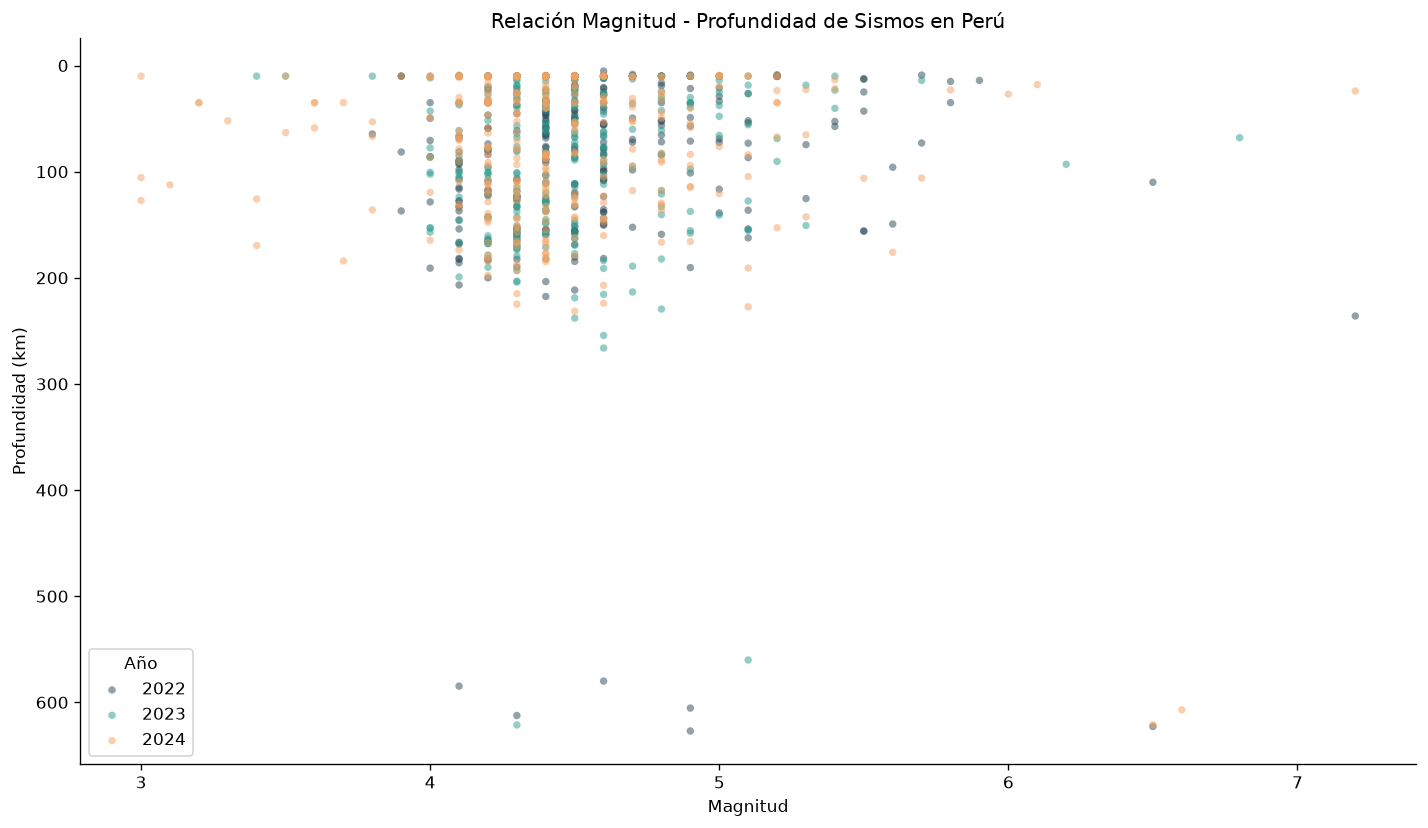

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

colores_anio = {2022: PALETA[0], 2023: PALETA[1], 2024: PALETA[3]}

for anio, grupo in sismos.groupby("anio"):
    ax.scatter(
        grupo["magnitud"], grupo["profundidad_km"],
        c=colores_anio[anio], alpha=0.5, s=20,
        label=str(anio), edgecolors="none",
    )

ax.set_xlabel("Magnitud")
ax.set_ylabel("Profundidad (km)")
ax.set_title("Relación Magnitud - Profundidad de Sismos en Perú")
ax.invert_yaxis()
ax.legend(title="Año")
plt.tight_layout()
plt.show()

## Distribución de Magnitudes (Gutenberg-Richter)

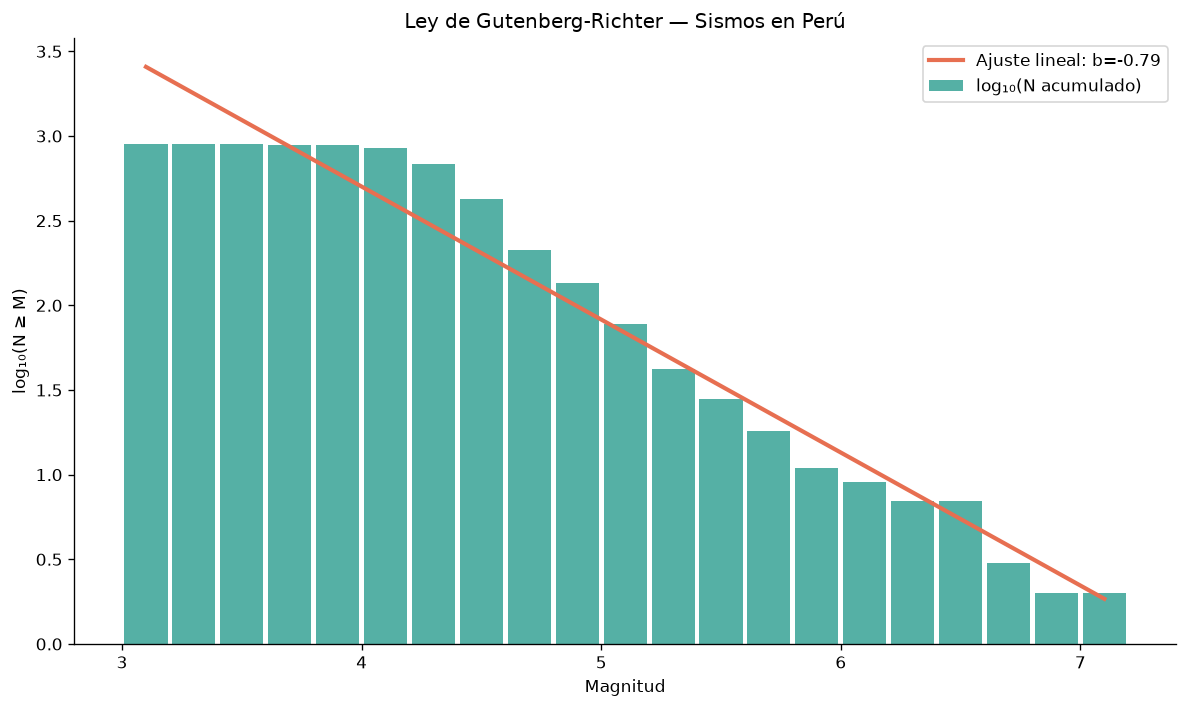

In [5]:
bins_mag = np.arange(3.0, sismos["magnitud"].max() + 0.2, 0.2)
conteos, bordes = np.histogram(sismos["magnitud"], bins=bins_mag)
centros = (bordes[:-1] + bordes[1:]) / 2

acumulado = np.array([conteos[i:].sum() for i in range(len(conteos))])
mascara = acumulado > 0
log_n = np.log10(acumulado[mascara])
centros_validos = centros[mascara]

coefs = np.polyfit(centros_validos, log_n, 1)
linea_ajuste = np.polyval(coefs, centros_validos)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(centros, np.where(acumulado > 0, np.log10(acumulado), 0),
       width=0.18, color=PALETA[1], alpha=0.8, label="log₁₀(N acumulado)")
ax.plot(centros_validos, linea_ajuste, color=PALETA[4], linewidth=2.5,
        label=f"Ajuste lineal: b={coefs[0]:.2f}")

ax.set_xlabel("Magnitud")
ax.set_ylabel("log₁₀(N ≥ M)")
ax.set_title("Ley de Gutenberg-Richter — Sismos en Perú")
ax.legend()
plt.tight_layout()
plt.show()

## Distribución mensual por año

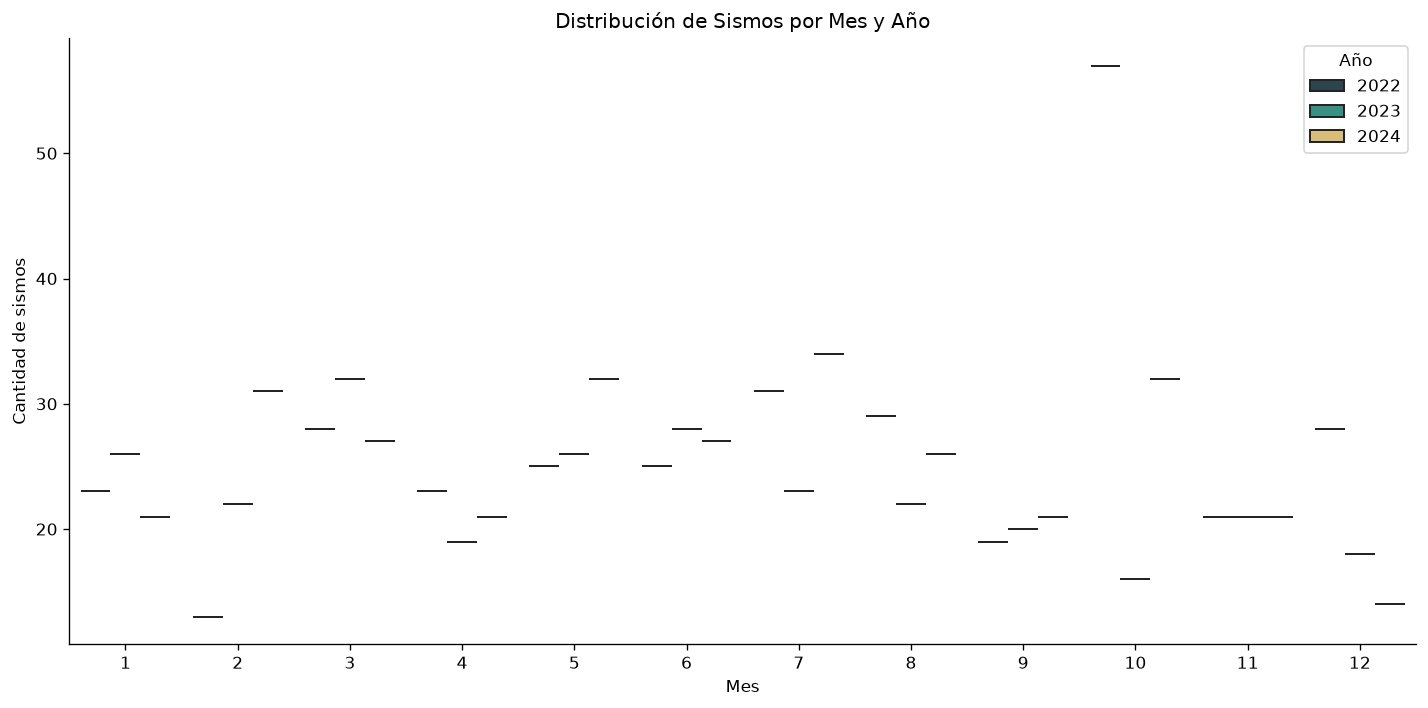

In [6]:
conteo_mensual = (
    sismos.groupby(["anio", "mes"])
    .size()
    .reset_index(name="cantidad")
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=conteo_mensual, x="mes", y="cantidad",
    hue="anio", palette=PALETA[:3], ax=ax,
    linewidth=1.2, fliersize=4,
)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de sismos")
ax.set_title("Distribución de Sismos por Mes y Año")
ax.legend(title="Año")
plt.tight_layout()
plt.show()

## Mapa interactivo de epicentros

In [7]:
muestra = sismos.copy()
muestra["texto"] = (
    "M" + muestra["magnitud"].astype(str)
    + " | Prof: " + muestra["profundidad_km"].round(1).astype(str) + " km"
    + "<br>" + muestra["lugar"]
)

fig_mapa = px.scatter_geo(
    muestra,
    lat="latitud",
    lon="longitud",
    size="magnitud",
    color="profundidad_km",
    hover_name="texto",
    color_continuous_scale="Viridis",
    size_max=14,
    title="Epicentros Sísmicos en Perú (2022-2024)",
    labels={"profundidad_km": "Profundidad (km)", "magnitud": "Magnitud"},
)
fig_mapa.update_geos(
    center={"lat": -9.19, "lon": -75.0},
    projection_scale=4.5,
    showland=True, landcolor="#f0efe9",
    showocean=True, oceancolor="#d6eaf8",
    showcountries=True, countrycolor="#888",
)
fig_mapa.update_layout(height=650, margin={"t": 50, "b": 10, "l": 10, "r": 10})
fig_mapa.show()

## Histograma interactivo de magnitudes

In [8]:
fig_hist = px.histogram(
    sismos,
    x="magnitud",
    nbins=40,
    color_discrete_sequence=[PALETA[1]],
    title="Distribución de Magnitudes Sísmicas",
    labels={"magnitud": "Magnitud", "count": "Cantidad"},
)
fig_hist.update_traces(hovertemplate="Magnitud: %{x:.1f}<br>Cantidad: %{y}")
fig_hist.update_layout(
    bargap=0.05,
    xaxis_title="Magnitud",
    yaxis_title="Cantidad de eventos",
    height=450,
)
fig_hist.show()

## Hallazgos principales

- La ley de Gutenberg-Richter se cumple de forma razonable para los datos peruanos.
- Los sismos superficiales (<70 km) dominan el registro, consistente con la subducción de la placa de Nazca.
- La zona costera sur concentra la mayor densidad de epicentros.